# Slime Mold Spatio-Temporal

In [5]:
#@title Setup (optional installs)
# !pip -q install tifffile h5py scikit-image tqdm
# !pip install zarr

In [6]:
#@title Imports & seed
import os, random, numpy as np, matplotlib.pyplot as plt, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import zarr as _z
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import torch.nn.functional as F


try:
    import tifffile as tiff
except Exception:
    tiff = None
try:
    import h5py
except Exception:
    h5py = None

def set_seed(seed=7):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(7); DEVICE

from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Load data (choose a reader and set `DATA_PATH`)

In [7]:
#@title Readers
DATA_PATH = "/content/drive/MyDrive/Data/mixin_test44/2024-01-17_ERH_23hr_ERH Red FarRed_t_subsampled.zarr"

def read_npy(path): return np.load(path)
def read_h5(path, key="images"):
    assert h5py is not None, "install h5py"
    import h5py as _h5
    with _h5.File(path, "r") as f: arr = f[key][:]
    return np.array(arr)
def read_tiff_stack(path):
    assert tiff is not None, "install tifffile"
    return np.asarray(tiff.imread(path))


# ------------ Loading the data using zarr --------------------------------------------------
def read_zarr(path, key = None):
    root = _z.open(path, mode="r")

    #1 Single array
    if isinstance(root, _z.Array):
        return np.array(root[:], dtype=np.float32)

    #2 Zarr Group
    if key is not None:
        return np.array(root[key][:], dtype=np.float32)

    #3 Load first sub array if no key was given
    arr_name, arr = list(root.arrays())[0]
    print(f"Loading first array '{arr_name}'")

    return np.array(arr[:], dtype=np.float32)

raw = read_zarr(DATA_PATH)
print("The shape of the data is (T, C, Z, H, W) =", raw.shape)
print("Where:")
print(f"  T = {raw.shape[0]}   is the number of timepoints")
print(f"  C = {raw.shape[1]}    is the number of imaging channels")
print(f"  Z = {raw.shape[2]}   is the number of z-slices per timepoint")
print(f"  H = {raw.shape[3]}  is the image height (pixels)")
print(f"  W = {raw.shape[4]}  is the image width  (pixels)")

# ------------- Converting the data to PyTorch tensor ----------------------------------------
class ToTensor(Dataset):
    def __init__(self, raw_array):
        self.raw = torch.tensor(raw_array, dtype=torch.float32)
    def __len__(self):
        return len(self.raw)
    def __getitem__(self, idx):
        return self.raw[idx]

# Printing
print()
print("Number of frames: ", len(ToTensor(raw)))
print("Shape of a single frame:", ToTensor(raw)[0].shape)


The shape of the data is (T, C, Z, H, W) = (34, 1, 32, 256, 256)
Where:
  T = 34   is the number of timepoints
  C = 1    is the number of imaging channels
  Z = 32   is the number of z-slices per timepoint
  H = 256  is the image height (pixels)
  W = 256  is the image width  (pixels)

Number of frames:  34
Shape of a single frame: torch.Size([1, 32, 256, 256])


shape: (34, 256, 256) min/max: 584.0 43056.0


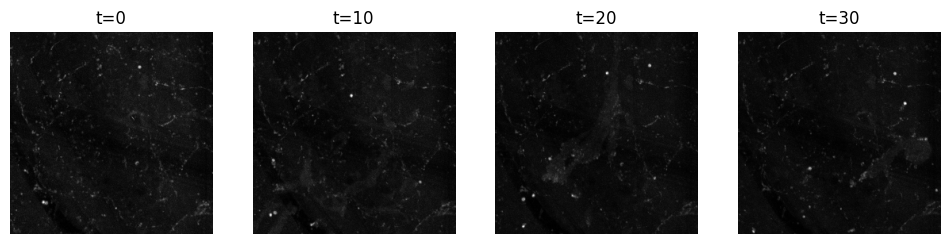

In [8]:
#@title Inspect & visualize a few frames
raw_2d = raw.max(axis=2).squeeze(1)
print("shape:", raw_2d.shape, "min/max:", float(raw_2d.min()), float(raw_2d.max()))

def show_frames(arr, frames=(0,10,20,30)):

    fig, axs = plt.subplots(1, len(frames), figsize=(12,3))
    for ax, t in zip(axs,frames):
        ax.imshow(arr[t], cmap="gray")
        ax.set_title(f"t={t}")
        ax.axis("off")
    plt.show()

show_frames(raw_2d)

At t = 0 the cells appear dispersed across the space with no apparent aggregation. By t = 10 very subtle intensity differences begin to form, and by t = 20 these patterns become clearer, showing early signs of aggregation. By t = 30 a more defined streaming-like pattern appears.

## 2) Dataset/Dataloader (sliding window next-frame prediction)

In [9]:
#@title Dataset & loaders
class WindowedFrames(Dataset):
    def __init__(self, arr, K=4):
        if arr.ndim==3:
          arr = arr[:, None, ...]
        self.arr = arr.astype(np.float32)
        self.K=K
    def __len__(self): return self.arr.shape[0]-self.K
    def __getitem__(self,i):
        x = torch.from_numpy(self.arr[i:i+self.K])     # (K,1,H,W)
        y = torch.from_numpy(self.arr[i+self.K])       # (1,H,W)
        return x,y

raw_2d = raw.max(axis=2).squeeze(1)
K=4; ds=WindowedFrames(raw_2d,K)
n_tr=int(0.7*len(ds)); n_val=int(0.15*len(ds)); n_te=len(ds)-n_tr-n_val
tr,val,te = random_split(ds,[n_tr,n_val,n_te],generator=torch.Generator().manual_seed(0))
tr_loader=DataLoader(tr,batch_size=16,shuffle=True); val_loader=DataLoader(val,batch_size=32); te_loader=DataLoader(te,batch_size=32)
len(tr),len(val),len(te)

(21, 4, 5)

## 3) Baseline model (Conv3D encoder → Conv2D head)

ep 05  tr 3358682.6667  val 3202296.7500
ep 10  tr 1327677.1071  val 874627.1875
ep 15  tr 657004.4792  val 630892.5000
ep 20  tr 350664.2545  val 345818.2188


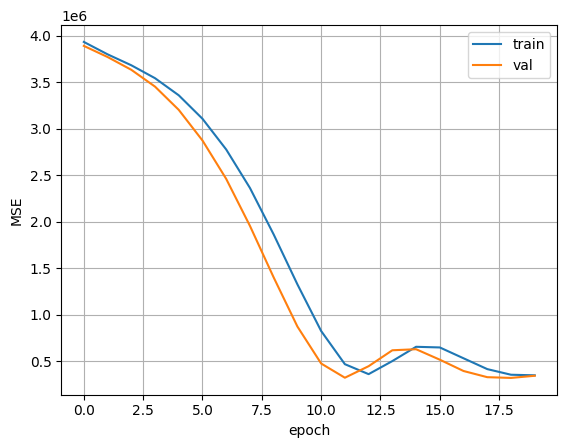

In [10]:
#@title Model, train, eval
class TinyCNN(nn.Module):
    def __init__(self,K):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv3d(1,8,kernel_size=(K,3,3),padding=(0,1,1)), nn.ReLU())
        self.head= nn.Sequential(nn.Conv2d(8,16,3,padding=1), nn.ReLU(), nn.Conv2d(16,1,1))

    def forward(self,x):
        x = x.permute(0,2,1,3,4)   # (B,1,K,H,W)
        z = self.enc(x).squeeze(2) # (B,8,H,W)
        return self.head(z)

model = TinyCNN(K).to(DEVICE); opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5); loss_fn = nn.MSELoss()

def train_epoch(model,loader):
    model.train(); total=0.0
    for xb,yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); pred = model(xb); loss = loss_fn(pred,yb); loss.backward(); opt.step()
        total += loss.item()*xb.size(0)
    return total/len(loader.dataset)

@torch.no_grad()
def evaluate(model,loader):
    model.eval(); total=0.0
    for xb,yb in loader:
        xb,yb = xb.to(DEVICE), yb.to(DEVICE)
        total += loss_fn(model(xb), yb).item()*xb.size(0)
    return total/len(loader.dataset)

hist_tr, hist_val = [], []
for ep in range(1,21):
    tr = train_epoch(model,tr_loader); va = evaluate(model,val_loader)
    hist_tr.append(tr); hist_val.append(va)
    if ep%5==0: print(f"ep {ep:02d}  tr {tr:.4f}  val {va:.4f}")

plt.figure(); plt.plot(hist_tr,label="train"); plt.plot(hist_val,label="val"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.grid();plt.show()

## 4) Qualitative prediction

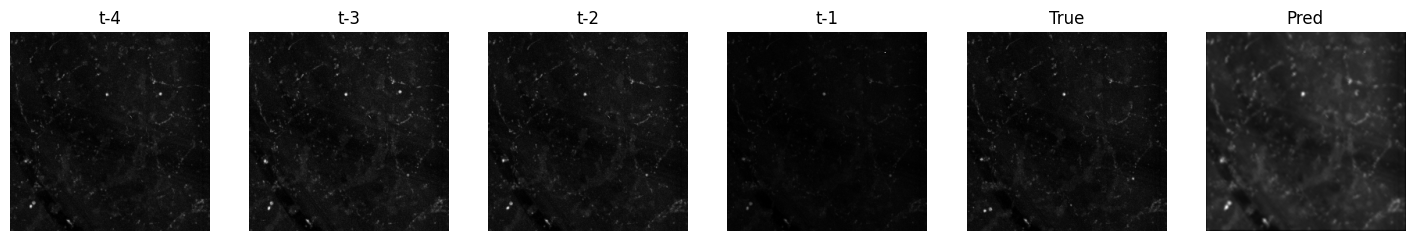

In [11]:
#@title Show one prediction
@torch.no_grad()
def show_example(i=0):
    xb,yb = ds[i]
    pred = model(xb.unsqueeze(0).to(DEVICE)).cpu().squeeze().numpy()
    true = yb.squeeze().numpy()
    hist = xb[:,0].numpy()
    cols = hist.shape[0]+2
    fig,axs = plt.subplots(1,cols, figsize=(3*cols,3))
    for k in range(hist.shape[0]):
        axs[k].imshow(hist[k], cmap="gray"); axs[k].set_title(f"t-{hist.shape[0]-k}"); axs[k].axis("off")
    axs[-2].imshow(true, cmap="gray"); axs[-2].set_title("True"); axs[-2].axis("off")
    axs[-1].imshow(pred, cmap="gray"); axs[-1].set_title("Pred"); axs[-1].axis("off")
    plt.show()
show_example(5)

-----------
## 5) Functions for Metrics

Below are functions used to calculate the center error (μm and pixels) and the spatial map quality (AUC and Average Precision, AP) for each model later on.

In [12]:
def compute_centroid(image):
  H,W = image.shape
  y,x = np.mgrid[0:H, 0:W]
  image = image.astype(np.float32)
  total_mass = image.sum() + 1e-8
  center_x = (x * image).sum() / total_mass
  center_y = (y * image).sum() / total_mass
  return center_x, center_y


def make_heatmap_gaussian(the_shape, center_x, center_y, sigma=5.0):
  H,W = the_shape
  y,x = np.mgrid[0:H, 0:W]

  dist = (x - center_x)**2 + (y - center_y)**2
  heatmap = np.exp(-dist / (2 * sigma**2))
  heatmap /= heatmap.max() + 1e-8
  return heatmap.astype(np.float32)

In [13]:
def compute_center_error(model, loader, pixel_size_um = 2.41, return_all = False): #2.41 from the excel-sheet on the dataset
  model.eval()
  errors_um = [] #Centroid errors in micrometers
  errors_pixels = [] #Centroid errors in pixels


  for xb, yb in loader: #xb = x_batch, yb = y_batch
      xb = xb.to(DEVICE)
      yb = yb.to(DEVICE) #(B,1,H,W)

      pred = model(xb).detach().cpu().numpy()
      true = yb.detach().cpu().numpy()

      pred = pred[:, 0, :, :]
      true = true[:, 0, :, :]

      for i in range(pred.shape[0]):
          pred_map = pred[i]
          true_map = true[i]

          cx_pred, cy_pred = compute_centroid(pred_map) #cx = center_x, cy = center_y
          cx_true, cy_true = compute_centroid(true_map)

          error_pixels_temp = np.sqrt((cx_pred - cx_true)**2 + (cy_pred - cy_true)**2)
          errors_um_temp = error_pixels_temp * pixel_size_um

          errors_pixels.append(error_pixels_temp)
          errors_um.append(errors_um_temp)

      mean_px = float(np.mean(errors_pixels))
      mean_um = float(np.mean(errors_um))

      if return_all:
          return mean_px, mean_um, np.array(errors_pixels), np.array(errors_um)

      return mean_px, mean_um


def compute_heatmap_quality(model, loader, threshold = 0.5, return_all = False):
  model.eval()
  auc_scores = []
  ap_scores = []

  for xb, yb in loader:
      xb = xb.to(DEVICE)
      yb = yb.to(DEVICE)

      pred = model(xb).detach().cpu().numpy()
      true = yb.detach().cpu().numpy() #(B,1,H,W)

      pred = pred[:, 0, :, :]
      true = true[:, 0, :, :]

      for p, t in zip(pred, true):
          p_flat = p.reshape(-1)
          t_flat = t.reshape(-1)

          # Spot or Background point
          true_binary = (t_flat > threshold).astype(np.uint8)

          # Skip all zeros or all ones
          if true_binary.sum() == 0 or true_binary.sum() == len(true_binary):
              continue

          # Keep the AUC and AP scores
          auc_scores.append(roc_auc_score(true_binary, p_flat))
          ap_scores.append(average_precision_score(true_binary, p_flat))

  mean_auc = float(np.mean(auc_scores)) if auc_scores else float("nan")
  mean_ap  = float(np.mean(ap_scores))  if ap_scores  else float("nan")

  if return_all:
      return mean_auc, mean_ap, np.array(auc_scores), np.array(ap_scores)

  return mean_auc, mean_ap

## 6) Model 1/Baseline: Tiny CNN



*   Here a small CNN network is applied. The model takes short sequences of frames as input and learns to predict heatmaps showing the final aggregation center.
*   The model is trained using the mean square error (MSE) loss with the Adam optimizer. The learning rate is lr = 10^-3. The train/test/validation split is 0.7/0.15/0.15 respectively.







In [14]:
class FinalHeatmapDataset(Dataset):
    """
    Cuts the movie/dataset into K frames and assigns each frame a Gaussian heatmap marking the final aggregation center
    """
    def __init__(self, arr_2d, K=4, sigma=5.0):
      assert arr_2d.ndim == 3, "Expected shape (T, H, W)"
      self.K = K

      arr = arr_2d[:, None, ...].astype(np.float32)
      self.arr = arr
      self.T, _, self.H, self.W = arr.shape

      final_frame = arr_2d[-1]
      cx, cy = compute_centroid(final_frame)
      self.center = (cx, cy)

      heat_temp = make_heatmap_gaussian(final_frame.shape, cx, cy, sigma=sigma)
      self.heatmap = heat_temp[None, ...]

    def __len__(self): return self.T - self.K

    def __getitem__(self, i):
      x = self.arr[i : i + self.K]
      y = self.heatmap

      return torch.from_numpy(x), torch.from_numpy(y)

In [15]:
K = 4; fhd_ds = FinalHeatmapDataset(raw_2d, K=K, sigma=5.0)
n_tr  = int(0.7 * len(fhd_ds)); n_val = int(0.15 * len(fhd_ds)); n_te  = len(fhd_ds) - n_tr - n_val

fhd_tr, fhd_val, fhd_te = random_split(fhd_ds,[n_tr, n_val, n_te],generator=torch.Generator().manual_seed(0))

fhd_tr_loader = DataLoader(fhd_tr, batch_size=4, shuffle=True)
fhd_val_loader = DataLoader(fhd_val, batch_size=4)
fhd_te_loader  = DataLoader(fhd_te, batch_size=4)

# Printing how a single batch looks like
xb, yb = next(iter(fhd_tr_loader)) # xb = input batch, yb = target batch
print("Input batch shape:", xb.shape) # (B, K, 1, H, W)
print("Target batch shape:", yb.shape) # (B, 1, H, W)


Input batch shape: torch.Size([4, 4, 1, 256, 256])
Target batch shape: torch.Size([4, 1, 256, 256])


ep 05  tr 1832.1874  val 824.2774
ep 10  tr 543.8700  val 511.9029
ep 15  tr 404.6599  val 389.9878
ep 20  tr 326.3451  val 314.2993


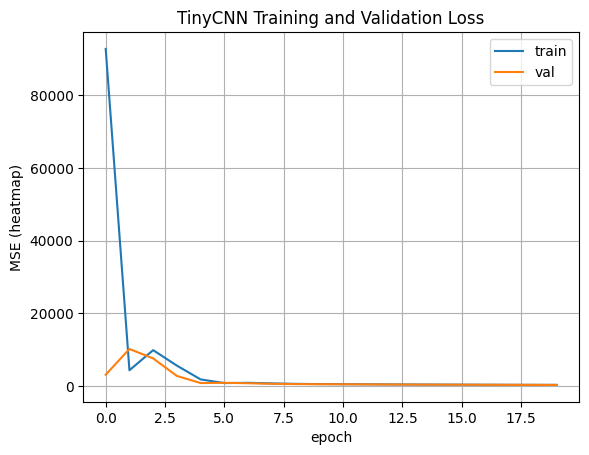

In [16]:
model1 = TinyCNN(K).to(DEVICE); opt1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

def train_epoch(model, loader, opt):
    model.train(); total=0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        total += loss.item()*xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); total=0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        total += loss_fn(model(xb), yb).item()*xb.size(0)
    return total / len(loader.dataset)

hist_tr, hist_val = [], []
for ep in range(1, 21):
    tr = train_epoch(model1, fhd_tr_loader, opt1); va = evaluate(model1, fhd_val_loader)
    hist_tr.append(tr); hist_val.append(va)
    if ep % 5 == 0: print(f"ep {ep:02d}  tr {tr:.4f}  val {va:.4f}")

plt.figure(); plt.plot(hist_tr, label="train"); plt.plot(hist_val, label="val"); plt.legend(); plt.grid()
plt.title('TinyCNN Training and Validation Loss'); plt.xlabel("epoch"); plt.ylabel("MSE (heatmap)"); plt.show()

In [17]:
# Metics model 1
model1_err_px, model1_err_um = compute_center_error(model1, fhd_te_loader)
model1_auc, model1_ap = compute_heatmap_quality(model1, fhd_te_loader)

print("Model 1: TinyCNN metrics")
print("-" * 40)
print(f"{'Center error (px / µm)':25} {model1_err_px:.2f} / {model1_err_um:.2f}")
print(f"{'Heatmap AUROC':25} {model1_auc:.4f}")
print(f"{'Average Precision':25} {model1_ap:.4f}")
print("-" * 40)

Model 1: TinyCNN metrics
----------------------------------------
Center error (px / µm)    187.00 / 450.68
Heatmap AUROC             0.4811
Average Precision         0.0016
----------------------------------------


## 7) Model 2: LSTM

* Here an LSTM model is applied. The model first uses a CNN to extract spatial features from each frame (the CNN uses ReLU activations and padded 3x3 convolutions). These features are then passed through the LSTM which learns temporal patterns across the sequence. The final hidden state is mapped to a heatmap showing the predicted final aggregation center.

*   The model is trained using the mean square error (MSE) loss with the Adam optimizer. The learning rate is lr = 10^-3. The train/test/validation split is 0.7/0.15/0.15 respectively.

In [18]:
class LSTM(nn.Module):
  def __init__(self, H, W, feature_dim=32, hidden_dim=64):
        super().__init__()
        self.H = H
        self.W = W

        self.cnn = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1),nn.ReLU(), nn.Conv2d(16, feature_dim, 3, padding=1), nn.ReLU())
        self.lstm = nn.LSTM(input_size=feature_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_dim, H * W)

  def forward(self, x):
          B, K, C, H, W = x.shape

          x = x.view(B * K, 1, H, W)
          feat_map = self.cnn(x)
          feat_vector = feat_map.mean(dim = [2, 3])

          feat_seq = feat_vector.view(B, K, -1)
          _, (h_last, _) = self.lstm(feat_seq)
          h_last = h_last[0]

          # predicting heatmap
          heatmap = self.fc(h_last)
          heatmap = heatmap.view(B, 1, H, W)

          return heatmap


epoch 01  train 0.0554  val 0.0418
epoch 02  train 0.0359  val 0.0234
epoch 03  train 0.0192  val 0.0129
epoch 04  train 0.0146  val 0.0364
epoch 05  train 0.0332  val 0.0329
epoch 06  train 0.0245  val 0.0136
epoch 07  train 0.0110  val 0.0069
epoch 08  train 0.0080  val 0.0070
epoch 09  train 0.0063  val 0.0039
epoch 10  train 0.0043  val 0.0020
epoch 11  train 0.0016  val 0.0043
epoch 12  train 0.0043  val 0.0036
epoch 13  train 0.0029  val 0.0017
epoch 14  train 0.0012  val 0.0006
epoch 15  train 0.0005  val 0.0003
epoch 16  train 0.0003  val 0.0002
epoch 17  train 0.0002  val 0.0002
epoch 18  train 0.0001  val 0.0001
epoch 19  train 0.0001  val 0.0001
epoch 20  train 0.0001  val 0.0000


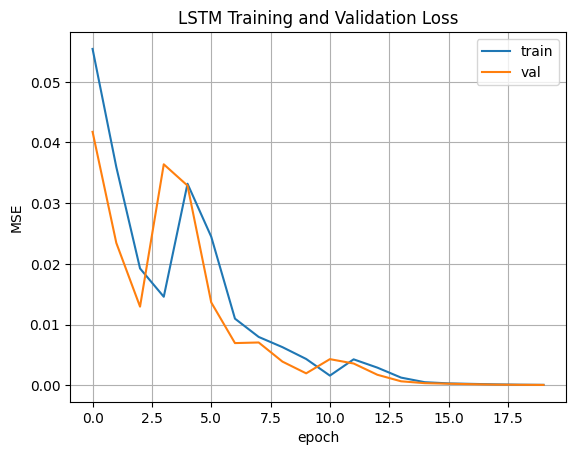

In [19]:
H, W = raw_2d.shape[1], raw_2d.shape[2]

model2 = LSTM(H, W).to(DEVICE)
opt2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

def train_one_epoch(model, loader, opt):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)   # xb: (B,K,1,H,W), yb: (B,1,H,W)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_mse(model, loader):
    model.eval()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)

hist_tr_lstm, hist_val_lstm = [], []


for ep in range(1, 21):  # 20 epochs
    tr = train_one_epoch(model2, fhd_tr_loader, opt2); va = eval_mse(model2, fhd_val_loader)
    hist_tr_lstm.append(tr); hist_val_lstm.append(va)
    print(f"epoch {ep:02d}  train {tr:.4f}  val {va:.4f}")

plt.figure(); plt.plot(hist_tr_lstm, label="train"); plt.plot(hist_val_lstm, label="val"); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("LSTM Training and Validation Loss"); plt.legend(); plt.grid(); plt.show()

In [20]:
# Metics model 2
model2_err_px, model2_err_um = compute_center_error(model2, fhd_te_loader)
model2_auc, model2_ap = compute_heatmap_quality(model2, fhd_te_loader)

print("Model 2: LSTM metrics")
print("-" * 40)
print(f"{'Center error (px / µm)':25} {model2_err_px:.2f} / {model2_err_um:.2f}")
print(f"{'Heatmap AUROC':25} {model2_auc:.4f}")
print(f"{'Average Precision':25} {model2_ap:.4f}")
print("-" * 40)


Model 2: LSTM metrics
----------------------------------------
Center error (px / µm)    0.36 / 0.87
Heatmap AUROC             1.0000
Average Precision         0.9922
----------------------------------------


## 8) Model 3: Small U-Net

*   Here a small U-net architecture is applied. Again the model takes a single frame as input and predicts a heatmap showing the final  aggregation center. The encoder uses two convolution layers with ReLU and max-pooling to extract features. The bottleneck processes these features before the decoder upsamples them back to the original size. Skip connections link encoder and decoder features which help the model preserve finer spatial details. See diagram below that explains the architecture.
*   The model is trained using the mean square error (MSE) loss with the Adam optimizer. The learning rate is lr = 10^-3. The train/test/validation split is 0.7/0.15/0.15 respectively.



In [21]:
# Encoder --> (Compress) --> Bottleneck --> (Upsample) --> Decoder
#     \_______________________________________________________/
#                           Skip Connection

In [22]:
class SmallUNet(nn.Module):
  def __init__(self, in_ch=1, out_ch=1):
        super().__init__()

        #Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)

        #Bottleneck
        self.bottle  = nn.Sequential(nn.Conv2d(32,32,3,padding=1), nn.ReLU())

        #Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.decode2 = nn.Sequential(nn.Conv2d(32+32,16,3,padding=1), nn.ReLU())
        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.decode1 = nn.Sequential(nn.Conv2d(16+16,16,3,padding=1), nn.ReLU())

        self.out = nn.Conv2d(16, out_ch, 1)

  def forward(self, x):
        #Encoder
        enc1_out = self.enc1(x) #(B,16,H,W)
        enc2_out = self.enc2(self.pool1(enc1_out)) #(B,32,H/2,W/2)

        bottleneck_out = self.bottle(self.pool2(enc2_out)) #(B,32,H/4,W/4)

        #Decoder
        up2_out = self.up2(bottleneck_out)
        dec2_out = self.decode2(torch.cat([up2_out, enc2_out], dim=1))

        up1_out = self.up1(dec2_out)
        dec1_out = self.decode1(torch.cat([up1_out, enc1_out], dim=1))

        return self.out(dec1_out)

epoch 01  train=6733.3896  val=2411.9392
epoch 02  train=2024.6022  val=744.5998
epoch 03  train=862.6818  val=447.4427
epoch 04  train=472.4074  val=337.4157
epoch 05  train=317.9929  val=236.7475
epoch 06  train=235.7645  val=204.4172
epoch 07  train=192.4666  val=177.9045
epoch 08  train=161.2945  val=151.6260
epoch 09  train=137.2489  val=129.0012
epoch 10  train=118.0610  val=110.8218
epoch 11  train=102.3626  val=95.4482
epoch 12  train=89.1051  val=83.0019
epoch 13  train=78.2890  val=74.7088
epoch 14  train=70.3647  val=67.8045
epoch 15  train=64.1706  val=61.7062
epoch 16  train=58.8536  val=56.6959
epoch 17  train=54.0950  val=52.2568
epoch 18  train=49.8181  val=47.6105
epoch 19  train=44.4102  val=40.1485
epoch 20  train=37.9728  val=36.6734


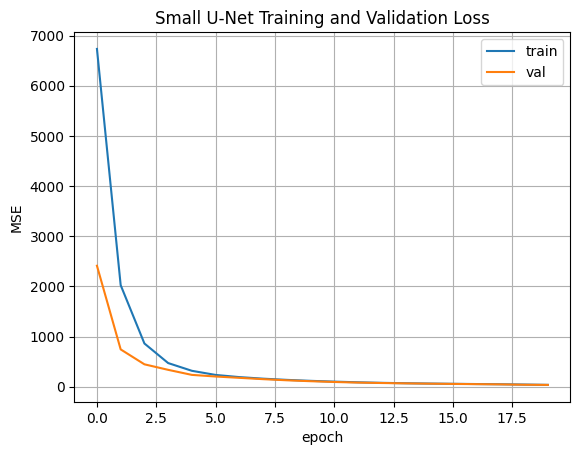

In [23]:
model3 = SmallUNet(in_ch=1, out_ch=1).to(DEVICE)
opt3 = torch.optim.Adam(model3.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 20
hist_tr3, hist_val3 = [], []

for ep in range(num_epochs):
    # Training
    model3.train(); running_tr = 0.0

    for xb, yb in fhd_tr_loader: # xb = input seq and yb = target
        xb, yb = xb.to(DEVICE), yb.to(DEVICE) # xb = B,K,1,H,W), yb = (B,1,H,W)

        last_frame = xb[:, -1]
        opt3.zero_grad()
        pred = model3(last_frame)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt3.step()

        running_tr += loss.item() * xb.size(0)

    epoch_tr_temp = running_tr / len(fhd_tr_loader.dataset)
    hist_tr3.append(epoch_tr_temp)

    # Validation
    model3.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in fhd_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            x2d = xb[:, -1]
            pred = model3(x2d)
            loss = loss_fn(pred, yb)
            running_val += loss.item() * xb.size(0)

    epoch_val_temp = running_val / len(fhd_val_loader.dataset)
    hist_val3.append(epoch_val_temp)

    print(f"epoch {ep+1:02d}  train={epoch_tr_temp:.4f}  val={epoch_val_temp:.4f}")

plt.figure(); plt.plot(hist_tr3, label="train"); plt.plot(hist_val3, label="val"); plt.xlabel("epoch")
plt.ylabel("MSE"); plt.title("Small U-Net Training and Validation Loss"); plt.legend(); plt.grid(); plt.show()

In [24]:
# Metics model 3
class LastFrameWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        if x.dim() == 5: #(B,K,1,H,W)
            x = x[:, -1] #(B,1,H,W)
        return self.base_model(x)

wrapped_model3 = LastFrameWrapper(model3).to(DEVICE)
model3_err_px, model3_err_um = compute_center_error(wrapped_model3, fhd_te_loader)
model3_auc, model3_ap = compute_heatmap_quality(wrapped_model3, fhd_te_loader)

print("Model 3: U-Net metrics")
print("-" * 40)
print(f"{'Center error (px / µm)':25} {model3_err_px:.2f} / {model3_err_um:.2f}")
print(f"{'Heatmap AUROC':25} {model3_auc:.4f}")
print(f"{'Average Precision':25} {model3_ap:.4f}")
print("-" * 40)

Model 3: U-Net metrics
----------------------------------------
Center error (px / µm)    11.63 / 28.02
Heatmap AUROC             0.5266
Average Precision         0.0016
----------------------------------------


## 9) Evaluation: Computing the mean ± CI

In [25]:
# Computing the mean ± CI

def mean_CI(values, alpha=0.05):
    vals = np.array(values, dtype=float)

    if len(vals) == 0: return float("nan"), float("nan"), float("nan")
    mean = float(vals.mean())
    if len(vals) > 1:
        se = vals.std(ddof=1) / np.sqrt(len(vals)) #Standard error
        z = 1.96 #95% CI
        low = mean - z * se
        high = mean + z * se
    else:
        low = high = mean

    return mean, low, high

models = {"TinyCNN": model1, "LSTM": model2, "SmallUNet": wrapped_model3}

rows = []

for name, the_model in models.items():
    #Center error (px, µm)
    mean_px, mean_um, errs_px, errs_um = compute_center_error(the_model, fhd_te_loader, return_all=True)
    mean_px, lo_px, hi_px = mean_CI(errs_px)
    mean_um, lo_um, hi_um = mean_CI(errs_um)

    half_px = hi_px - mean_px
    half_um = hi_um - mean_um

    #Heatmap metrics (AUROC, AP)
    mean_auc, mean_ap, aucs, aps = compute_heatmap_quality(the_model, fhd_te_loader, return_all=True)
    mean_auc, lo_auc, hi_auc = mean_CI(aucs)
    mean_ap, lo_ap, hi_ap = mean_CI(aps)

    half_auc = hi_auc - mean_auc
    half_ap = hi_ap - mean_ap

    #For printing
    rows.append({
        "Model": name,
        "Center error (px)": f"{mean_px:.2f} ± {half_px:.2f}",
        "Center error (µm)": f"{mean_um:.2f} ± {half_um:.2f}",
        "AUROC": f"{mean_auc:.3f} ± {half_auc:.3f}",
        "Average Precision": f"{mean_ap:.3f} ± {half_ap:.3f}"})

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

    Model Center error (px) Center error (µm)         AUROC Average Precision
  TinyCNN   187.00 ± 101.81   450.68 ± 245.36 0.481 ± 0.070     0.002 ± 0.000
     LSTM       0.36 ± 0.00       0.87 ± 0.00 1.000 ± 0.000     0.992 ± 0.000
SmallUNet      11.63 ± 1.19      28.02 ± 2.87 0.527 ± 0.008     0.002 ± 0.000


## 10) Evaluation: Early frames with predicted hotspot and center overlayed

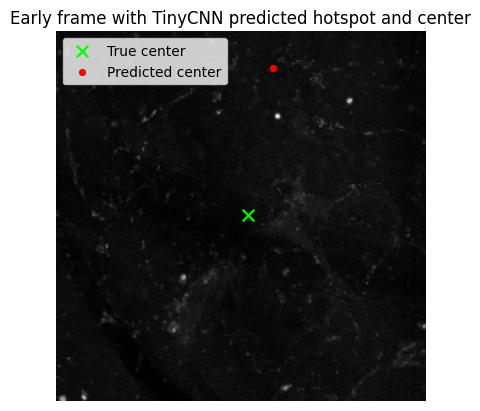

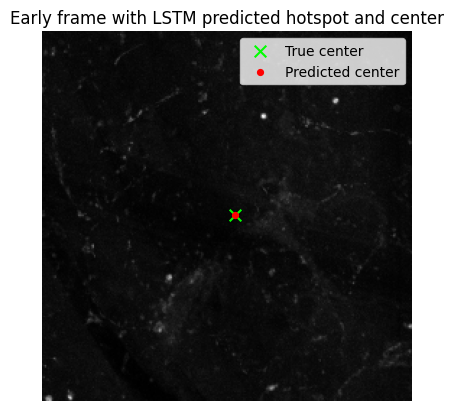

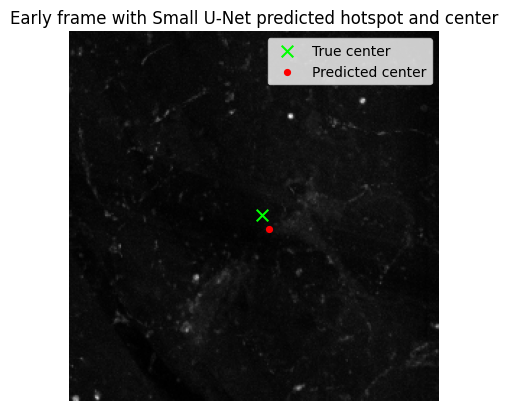

In [26]:
@torch.no_grad()
def plot_prediction_overlay(model, loader, a_title):
    model.eval()

    #First batch
    xb, yb = next(iter(loader)) #xb = (B,K,1,H,W), yb = (B,1,H,W)

    #First example in the batch
    xb0 = xb[0] #(K,1,H,W)
    yb0 = yb[0] #(1,H,W)

    K = xb0.shape[0]
    early_frame = xb0[-1, 0].cpu().numpy()

    #Run model on sequence
    pred = model(xb0.unsqueeze(0).to(DEVICE)).cpu().numpy()[0, 0] #(H,W)
    true = yb0.cpu().numpy()[0]

    cx_pred, cy_pred = compute_centroid(pred)
    cx_true, cy_true = compute_centroid(true)

    #Plotting
    plt.figure(); plt.imshow(early_frame, cmap="gray");
    plt.scatter([cx_true], [cy_true], marker="x", s=70, label="True center", color="lime")
    plt.scatter([cx_pred], [cy_pred], marker=".", s=70, label="Predicted center", color="red")
    plt.axis("off"); plt.legend(); plt.title(f"Early frame with {a_title} predicted hotspot and center")
    plt.show()


plot_prediction_overlay(model1, fhd_te_loader, "TinyCNN")
plot_prediction_overlay(model2, fhd_te_loader,  "LSTM")
plot_prediction_overlay(wrapped_model3, fhd_te_loader, "Small U-Net")


## 11) Evaluation: Error vs. Available Frames

This evaluation is done for the best performing model (LSTM):

In [6]:
class SubsetDataset(Dataset):
    def __init__(self, base_dataset, use_frames):
        self.base_dataset = base_dataset #Original dataset
        self.use_frames = use_frames #Number of frames to keep

    def __len__(self): return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y = self.base_dataset[idx]
        x = x.clone()
        K = x.shape[0]

        print("x shape:", x.shape)
        exit()
        if self.use_frames < K: x[:, self.use_frames:] = 0.0

        return x, y

@torch.no_grad()
def error_vs_available_frames(model, base_dataset, pixel_size_um=2.41):
    K = list(range(1, base_dataset.K + 1)) #Frames
    errors_um = []

    for N in K:
        subset_ds = SubsetDataset(base_dataset, use_frames=N)
        subset_loader = DataLoader(subset_ds, batch_size=32)
        _, mean_um = compute_center_error(model, subset_loader, pixel_size_um=pixel_size_um)
        errors_um.append(mean_um)
        print(f"N={N}: mean center error = {mean_um:.2f} µm")

    plt.figure()
    plt.plot(K, errors_um, marker="o"); plt.xlabel("Number of available frames N"); plt.ylabel("Center error (µm)")
    plt.title("Error vs. Available Frames (LSTM Model)"); plt.grid(); plt.show()

error_vs_available_frames(model2, fhd_ds)



NameError: name 'Dataset' is not defined

The LSTM becomes fairly accurate by frame 3, and by frame 4 it predicts the aggregation center correctly.

## 12) Evaluation: Resolution Robustness

This metric shows how predictions hold up when trained on high-res but tested on subsampled data. Measured using relative performance drop (%).

In [5]:
@torch.no_grad()
def resolution_robustness(model, loader, resolution=(1.0, 0.5, 0.25), pixel_size_um=2.41):

    results = []

    model.eval()
    for i in resolution:
        errors_um = []

        for xb, yb in loader:
            xb = xb.to(DEVICE) #(B,K,1,H,W)
            yb = yb.to(DEVICE) #(B,1,H,W)
            B, K, C, H, W = xb.shape

            #Downsample and upsample if needed
            if i != 1.0:
                new_H, new_W = int(H * i), int(W * i)
                flat = xb.view(B*K, C, H, W)
                flat = F.interpolate(flat, size=(new_H,new_W), mode='bilinear', align_corners=False)
                flat = F.interpolate(flat, size=(H,W), mode='bilinear', align_corners=False)
                xb2 = flat.view(B, K, C, H, W)
            else:
                xb2 = xb

            #Prediction
            pred = model(xb2).cpu().numpy()[:,0]
            true = yb.cpu().numpy()[:,0]

            #Computing the error
            for p, t in zip(pred, true):
                cxp, cyp = compute_centroid(p)
                cxt, cyt = compute_centroid(t)

                err_px = np.sqrt((cxp - cxt)**2 + (cyp - cyt)**2)
                errors_um.append(err_px * pixel_size_um)

        mean_um = float(np.mean(errors_um))
        results.append((i, mean_um))

    return results


NameError: name 'torch' is not defined

In [ ]:
resolution = (1.0, 0.5, 0.25)

models = {"TinyCNN": model1, "LSTM": model2, "SmallUNet": wrapped_model3}

results_by_model = {}

for name, the_model in models.items():
    a_result = resolution_robustness(the_model, fhd_te_loader, resolution=resolution)
    results_by_model[name] = a_result

#Printing
for name, a_result in results_by_model.items():
    print(f"\nModel: {name}")
    print(" Resolution |  error (µm) | drop vs 1.0 resolution (%)")
    print("--------------------------------------")
    full_err = a_result[0][1]
    for a_resolution, err_um in a_result:
        the_drop = 0.0 if a_resolution == 1.0 else 100.0 * (err_um - full_err) / full_err
        print(f" {a_resolution:4.2f} | {err_um:10.2f} | {the_drop:14.1f}")

## 13) Conclusion

LSTM performs by far the best: by frame 3 it already predicts the aggregation center fairly accurately and by frame 4 it predicts it correctly. See the write-up for a more comprehensive explanation of code.